# Model Comparison

Load exported VADER, DistilBERT, and RoBERTa outputs and create comparison tables/plots.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
# load model-level overall results
vader_overall = pd.read_csv("vader_results_overall.csv")
distil_overall = pd.read_csv("distilbert_results_overall.csv")
roberta_overall = pd.read_csv("roberta_results_overall.csv")

# load tier-stratified results
vader_tier = pd.read_csv("vader_results_by_tier.csv")
distil_tier = pd.read_csv("distilbert_results_by_tier.csv")
roberta_tier = pd.read_csv("roberta_results_by_tier.csv")

In [ ]:
# read simple key:value stats text files (Pearson/ANOVA)
def read_stats(path):
    vals = {}
    with open(path, "r") as f:
        for line in f:
            if ":" in line:
                k, v = line.strip().split(":", 1)
                vals[k.strip()] = v.strip()
    return vals

vader_stats = read_stats("vader_stats.txt")
distil_stats = read_stats("distilbert_stats.txt")
roberta_stats = read_stats("roberta_stats.txt")

# build one summary row per model
rows = []
for model_name, overall_df, stats_dict, score_col, model_type in [
    ("VADER", vader_overall, vader_stats, "vader_mean", "Lexicon"),
    ("DistilBERT", distil_overall, distil_stats, "distilbert_mean", "Transformer"),
    ("RoBERTa", roberta_overall, roberta_stats, "roberta_mean", "Transformer"),
]:
    top_idx = overall_df[score_col].idxmax()
    low_idx = overall_df[score_col].idxmin()
    rows.append({
        "Model": model_name,
        "Correlation with Stars": float(stats_dict.get("Pearson r", np.nan)),
        "ANOVA F-statistic": float(stats_dict.get("ANOVA F", np.nan)),
        "ANOVA p-value": float(stats_dict.get("ANOVA p", np.nan)),
        "Highest scoring cuisine": overall_df.loc[top_idx, "cuisine_type"],
        "Lowest scoring cuisine": overall_df.loc[low_idx, "cuisine_type"],
        "Score range": overall_df[score_col].max() - overall_df[score_col].min(),
        "Model type": model_type,
    })

summary_df = pd.DataFrame(rows)
display(summary_df)
summary_df.to_csv("model_comparison_summary.csv", index=False)

,Model,Correlation with Stars,ANOVA F-statistic,ANOVA p-value,Highest scoring cuisine,Lowest scoring cuisine,Score range,Model type
0,VADER,0.703682,78.012048,1.348355e-144,French,American,0.164041,Lexicon
1,DistilBERT,0.824318,81.318136,6.256149e-151,Thai,American,0.138136,Transformer
2,RoBERTa,0.869508,2.358494,1.180686e-02,Thai,American,0.086629,Transformer


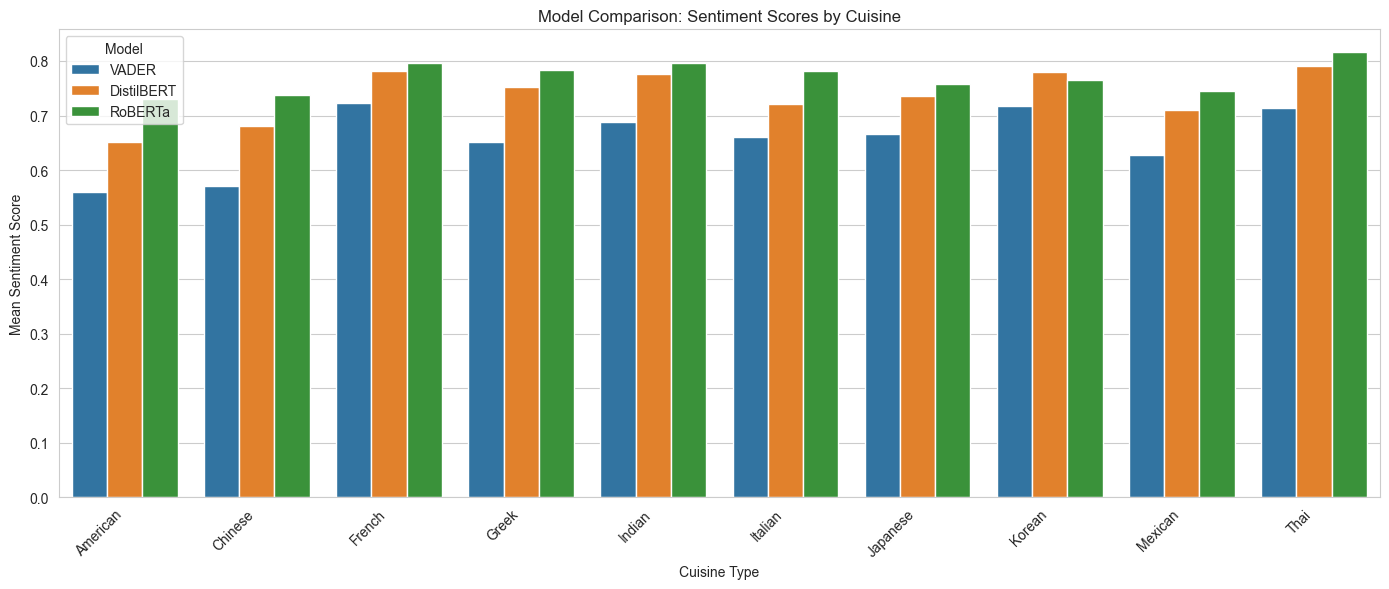

In [ ]:
# merge overall model outputs by cuisine
overall_merged = vader_overall[["cuisine_type", "vader_mean"]].merge(
    distil_overall[["cuisine_type", "distilbert_mean"]], on="cuisine_type", how="inner"
).merge(
    roberta_overall[["cuisine_type", "roberta_mean"]], on="cuisine_type", how="inner"
)

# reshape to long format for grouped bar plotting
bar_df = overall_merged.melt(
    id_vars="cuisine_type",
    value_vars=["vader_mean", "distilbert_mean", "roberta_mean"],
    var_name="model",
    value_name="mean_score",
)
bar_df["model"] = bar_df["model"].map({
    "vader_mean": "VADER",
    "distilbert_mean": "DistilBERT",
    "roberta_mean": "RoBERTa",
})

# side-by-side model comparison bars
plt.figure(figsize=(14, 6))
sns.barplot(data=bar_df, x="cuisine_type", y="mean_score", hue="model", palette=["#1f77b4", "#ff7f0e", "#2ca02c"])
plt.title("Model Comparison: Sentiment Scores by Cuisine")
plt.xlabel("Cuisine Type")
plt.ylabel("Mean Sentiment Score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig("model_comparison_bars.png", dpi=300)
plt.show()

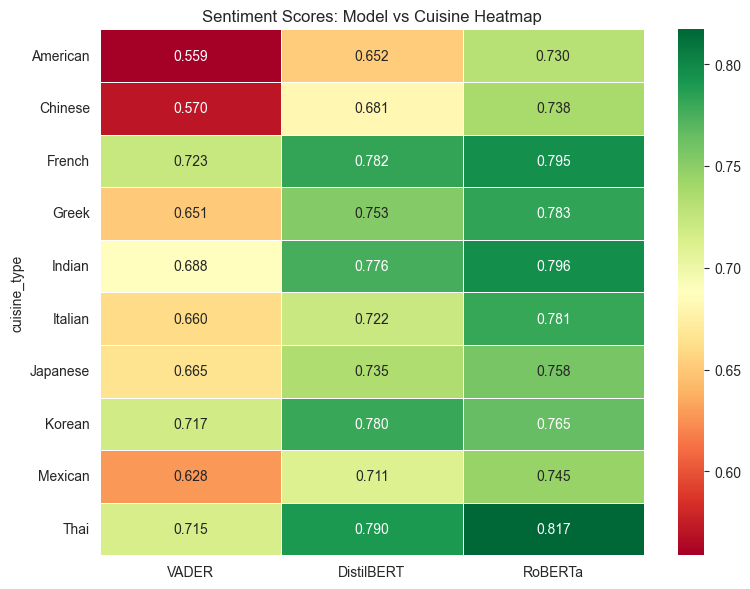

In [ ]:
# build cuisine x model matrix for heatmap
heat_df = overall_merged.set_index("cuisine_type").rename(columns={
    "vader_mean": "VADER",
    "distilbert_mean": "DistilBERT",
    "roberta_mean": "RoBERTa",
})

# heatmap of absolute sentiment score levels
plt.figure(figsize=(8, 6))
sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="RdYlGn", linewidths=0.5)
plt.title("Sentiment Scores: Model vs Cuisine Heatmap")
plt.tight_layout()
plt.savefig("model_comparison_heatmap.png", dpi=300)
plt.show()

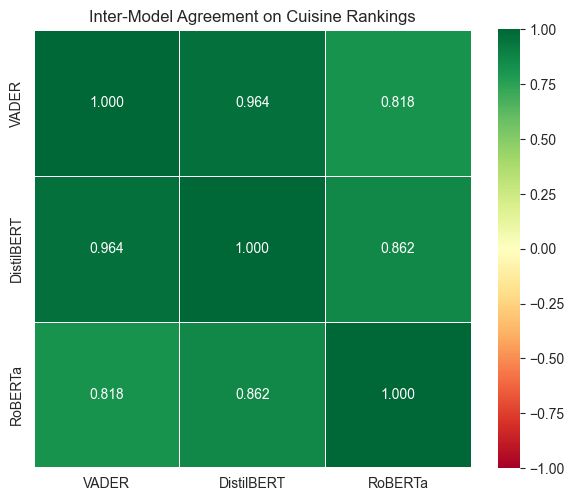

In [ ]:
# keep only model score columns and rename for display
model_scores = overall_merged[["vader_mean", "distilbert_mean", "roberta_mean"]].rename(columns={
    "vader_mean": "VADER",
    "distilbert_mean": "DistilBERT",
    "roberta_mean": "RoBERTa",
})

# correlation matrix = inter-model agreement on cuisine patterns
corr_matrix = model_scores.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="RdYlGn", vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Inter-Model Agreement on Cuisine Rankings")
plt.tight_layout()
plt.savefig("model_correlation_matrix.png", dpi=300)
plt.show()

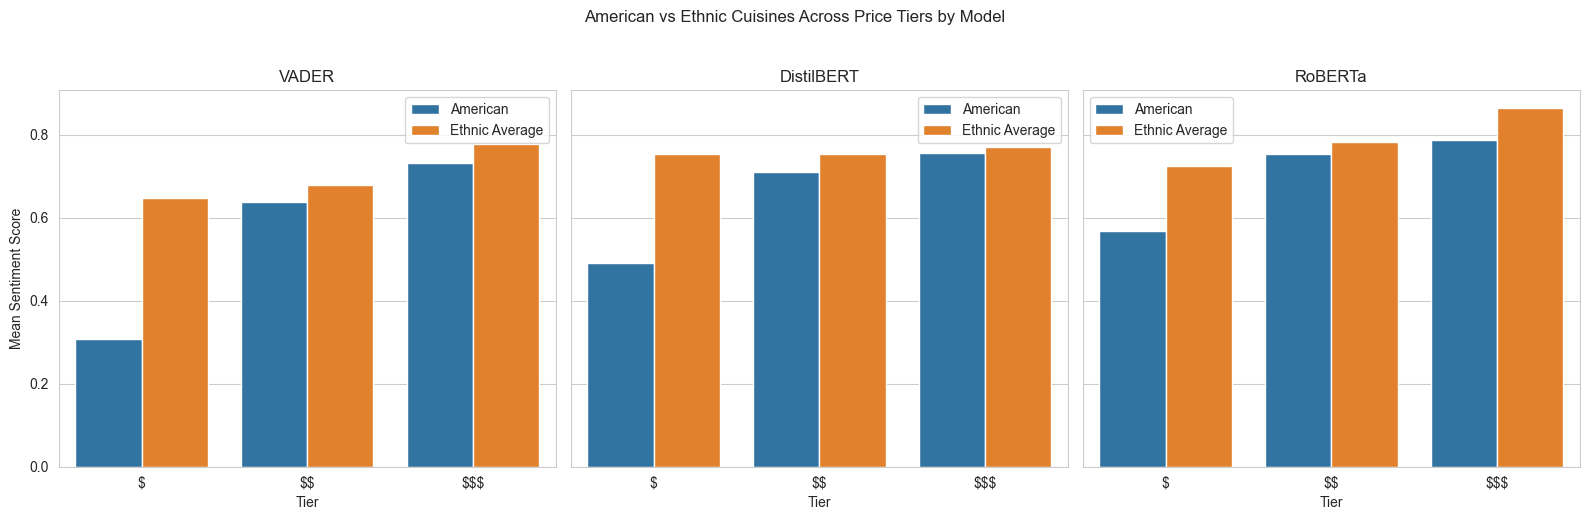

In [ ]:
# compare American vs ethnic-cuisine average in each price tier, for each model
tier_order = ["$", "$$", "$$$"]
tier_labels = {"$": r"\$", "$$": r"\$\$", "$$$": r"\$\$\$"}
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, model_name, df_tier, score_col in [
    (axes[0], "VADER", vader_tier, "vader_mean"),
    (axes[1], "DistilBERT", distil_tier, "distilbert_mean"),
    (axes[2], "RoBERTa", roberta_tier, "roberta_mean"),
]:
    rows = []
    for t in tier_order:
        d = df_tier[df_tier["tier"] == t]

        # American score at this tier
        am_vals = d.loc[d["cuisine_type"] == "American", score_col]
        # Average score across all non-American cuisines at this tier
        ethnic_vals = d.loc[d["cuisine_type"] != "American", score_col]

        american_score = am_vals.mean() if len(am_vals) else np.nan
        ethnic_avg = ethnic_vals.mean() if len(ethnic_vals) else np.nan
        rows.append({"tier": t, "tier_label": tier_labels[t], "American": american_score, "Ethnic Average": ethnic_avg})

    tier_cmp = pd.DataFrame(rows)
    plot_cmp = tier_cmp.melt(id_vars=["tier", "tier_label"], var_name="group", value_name="score")
    sns.barplot(data=plot_cmp, x="tier_label", y="score", hue="group", ax=ax, palette=["#1f77b4", "#ff7f0e"])
    ax.set_title(model_name)
    ax.set_xlabel("Tier")
    ax.set_ylabel("Mean Sentiment Score")
    ax.legend(title="")

plt.suptitle("American vs Ethnic Cuisines Across Price Tiers by Model", y=1.03)
plt.tight_layout()
plt.savefig("tier_comparison_all_models.png", dpi=300)
plt.show()
